<a href="https://colab.research.google.com/github/Aki-max-min/Self_Pruning_NeuralNetwork/blob/main/Self_Pruning_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import os
import math
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [38]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [39]:
BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
LAMBDA_VALUES = [1e-5, 5e-5, 1e-4]
SPARSITY_THRESHOLD = 1e-2
GATE_INIT = 2.0
DATA_ROOT = "./data"

In [55]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

train_dataset = datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


In [56]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True, gate_init=2.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.gate_scores = nn.Parameter(torch.empty(out_features, in_features))

        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            self.register_parameter("bias", None)

        self.reset_parameters(gate_init)

    def reset_parameters(self, gate_init=2.0):
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        nn.init.constant_(self.gate_scores, gate_init)

        if self.bias is not None:
            bound = 1 / math.sqrt(self.in_features)
            nn.init.uniform_(self.bias, -bound, bound)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)

    def get_effective_weight(self):
        return self.weight * self.get_gates()

    def forward(self, x):
        return F.linear(x, self.get_effective_weight(), self.bias)



In [57]:
class SelfPruningCNN(nn.Module):
    def __init__(self, gate_init=2.0):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 32 -> 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 16 -> 8

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            PrunableLinear(256, 256, gate_init=gate_init),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            PrunableLinear(256, 10, gate_init=gate_init)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def prunable_layers(self):
        return [m for m in self.modules() if isinstance(m, PrunableLinear)]

    def sparsity_loss(self):
        loss = 0.0
        for layer in self.prunable_layers():
            loss = loss + layer.get_gates().abs().sum()
        return loss

    def collect_all_gates(self):
        all_gates = []
        for layer in self.prunable_layers():
            all_gates.append(layer.get_gates().detach().view(-1))
        return torch.cat(all_gates)

    def sparsity_level(self, threshold=1e-2):
        gates = self.collect_all_gates()
        sparsity = (gates < threshold).float().mean().item() * 100.0
        return sparsity

def evaluate(model, loader, criterion, threshold=1e-2):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    acc = 100.0 * correct / total
    sparsity = model.sparsity_level(threshold)
    return avg_loss, acc, sparsity

def train_one_lambda(lambda_sparse):
    model = SelfPruningCNN(gate_init=GATE_INIT).to(device)
    criterion = nn.CrossEntropyLoss()

    gate_params = []
    normal_params = []

    for name, param in model.named_parameters():
        if "gate_scores" in name:
            gate_params.append(param)
        else:
            normal_params.append(param)

    optimizer = optim.Adam([
        {"params": normal_params, "lr": LEARNING_RATE, "weight_decay": WEIGHT_DECAY},
        {"params": gate_params, "lr": LEARNING_RATE, "weight_decay": 0.0}
    ])

    best_model_wts = copy.deepcopy(model.state_dict())
    best_test_acc = 0.0

    history = {
        "train_total_loss": [],
        "train_cls_loss": [],
        "train_sparse_loss": [],
        "test_loss": [],
        "test_acc": [],
        "sparsity": []
    }

    for epoch in range(EPOCHS):
        model.train()
        running_total_loss = 0.0
        running_cls_loss = 0.0
        running_sparse_loss = 0.0

        lambda_t = lambda_sparse * min(1.0, (epoch + 1) / 5.0)

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            cls_loss = criterion(outputs, labels)
            sparse_loss = model.sparsity_loss()
            total_loss = cls_loss + lambda_t * sparse_loss

            total_loss.backward()
            optimizer.step()

            running_total_loss += total_loss.item()
            running_cls_loss += cls_loss.item()
            running_sparse_loss += sparse_loss.item()

        avg_train_total = running_total_loss / len(train_loader)
        avg_train_cls = running_cls_loss / len(train_loader)
        avg_train_sparse = running_sparse_loss / len(train_loader)

        test_loss, test_acc, test_sparsity = evaluate(
            model, test_loader, criterion, threshold=SPARSITY_THRESHOLD
        )

        history["train_total_loss"].append(avg_train_total)
        history["train_cls_loss"].append(avg_train_cls)
        history["train_sparse_loss"].append(avg_train_sparse)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["sparsity"].append(test_sparsity)

        print(
            f"[lambda={lambda_sparse:.1e}] "
            f"Epoch {epoch+1:02d}/{EPOCHS} | "
            f"Train Total: {avg_train_total:.4f} | "
            f"Train CE: {avg_train_cls:.4f} | "
            f"Train Sparse: {avg_train_sparse:.2f} | "
            f"Test Acc: {test_acc:.2f}% | "
            f"Sparsity: {test_sparsity:.2f}%"
        )

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    final_test_loss, final_test_acc, final_sparsity = evaluate(
        model, test_loader, criterion, threshold=SPARSITY_THRESHOLD
    )

    return model, history, final_test_loss, final_test_acc, final_sparsity

def hard_prune_model(model, threshold=1e-2):
    pruned_model = copy.deepcopy(model)

    for layer in pruned_model.prunable_layers():
        with torch.no_grad():
            gates = layer.get_gates()
            mask = (gates >= threshold).float()
            layer.weight.mul_(mask)

            eps = 1e-8
            gate_vals = mask * (1 - eps) + (1 - mask) * eps
            layer.gate_scores.copy_(torch.log(gate_vals / (1 - gate_vals)))

    return pruned_model

results = []
best_model_info = None
best_acc = -1

for lam in LAMBDA_VALUES:
    print("\n" + "=" * 70)
    print(f"Training model for lambda = {lam}")
    print("=" * 70)

    model, history, test_loss, test_acc, sparsity = train_one_lambda(lam)

    criterion = nn.CrossEntropyLoss()
    hard_model = hard_prune_model(model, threshold=SPARSITY_THRESHOLD).to(device)
    hard_test_loss, hard_test_acc, hard_sparsity = evaluate(
        hard_model, test_loader, criterion, threshold=SPARSITY_THRESHOLD
    )

    result = {
        "lambda": lam,
        "soft_test_loss": test_loss,
        "soft_test_acc": test_acc,
        "soft_sparsity": sparsity,
        "hard_test_acc": hard_test_acc,
        "hard_sparsity": hard_sparsity,
        "history": history,
        "model": model
    }
    results.append(result)

    if test_acc > best_acc:
        best_acc = test_acc
        best_model_info = result



Training model for lambda = 1e-05
[lambda=1.0e-05] Epoch 01/20 | Train Total: 1.5106 | Train CE: 1.3913 | Train Sparse: 59651.60 | Test Acc: 55.37% | Sparsity: 0.00%
[lambda=1.0e-05] Epoch 02/20 | Train Total: 1.2198 | Train CE: 0.9858 | Train Sparse: 58489.69 | Test Acc: 63.62% | Sparsity: 0.00%
[lambda=1.0e-05] Epoch 03/20 | Train Total: 1.1778 | Train CE: 0.8392 | Train Sparse: 56445.85 | Test Acc: 53.03% | Sparsity: 0.00%
[lambda=1.0e-05] Epoch 04/20 | Train Total: 1.1575 | Train CE: 0.7278 | Train Sparse: 53712.12 | Test Acc: 70.46% | Sparsity: 0.00%
[lambda=1.0e-05] Epoch 05/20 | Train Total: 1.1623 | Train CE: 0.6548 | Train Sparse: 50747.50 | Test Acc: 74.19% | Sparsity: 0.00%
[lambda=1.0e-05] Epoch 06/20 | Train Total: 1.0831 | Train CE: 0.6018 | Train Sparse: 48131.22 | Test Acc: 72.64% | Sparsity: 0.00%
[lambda=1.0e-05] Epoch 07/20 | Train Total: 1.0167 | Train CE: 0.5567 | Train Sparse: 45997.04 | Test Acc: 79.15% | Sparsity: 0.00%
[lambda=1.0e-05] Epoch 08/20 | Train Tota


FINAL RESULTS
    Lambda | Soft Acc (%) |  Soft Sparsity (%) | Hard Acc (%) |  Hard Sparsity (%)
------------------------------------------------------------------------------------------
   1.0e-05 |        84.65 |               0.00 |        84.53 |               0.00
   5.0e-05 |        85.51 |               0.00 |        84.10 |               0.00
   1.0e-04 |        85.40 |               0.00 |        84.03 |               0.00


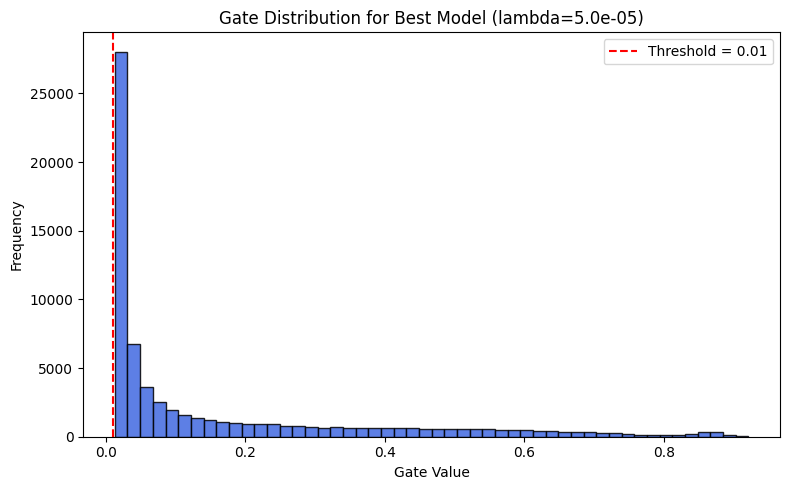


Best model saved to checkpoints/best_self_pruning_cnn.pth


In [58]:
print("\n" + "=" * 90)
print("FINAL RESULTS")
print("=" * 90)
print(f"{'Lambda':>10} | {'Soft Acc (%)':>12} | {'Soft Sparsity (%)':>18} | {'Hard Acc (%)':>12} | {'Hard Sparsity (%)':>18}")
print("-" * 90)

for r in results:
    print(f"{r['lambda']:>10.1e} | {r['soft_test_acc']:>12.2f} | {r['soft_sparsity']:>18.2f} | {r['hard_test_acc']:>12.2f} | {r['hard_sparsity']:>18.2f}")

best_model = best_model_info["model"]
all_gates = best_model.collect_all_gates().cpu().numpy()

plt.figure(figsize=(8, 5))
plt.hist(all_gates, bins=50, color="royalblue", edgecolor="black", alpha=0.85)
plt.axvline(SPARSITY_THRESHOLD, color="red", linestyle="--", label=f"Threshold = {SPARSITY_THRESHOLD}")
plt.title(f"Gate Distribution for Best Model (lambda={best_model_info['lambda']:.1e})")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

os.makedirs("checkpoints", exist_ok=True)
torch.save(best_model.state_dict(), "checkpoints/best_self_pruning_cnn.pth")
print("\nBest model saved to checkpoints/best_self_pruning_cnn.pth")

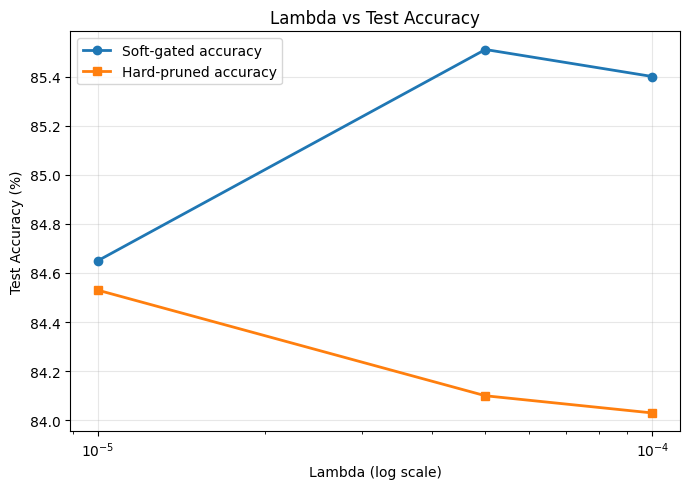

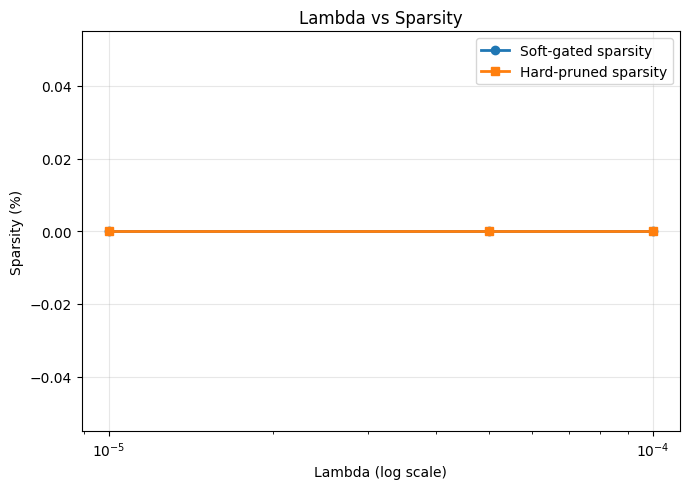

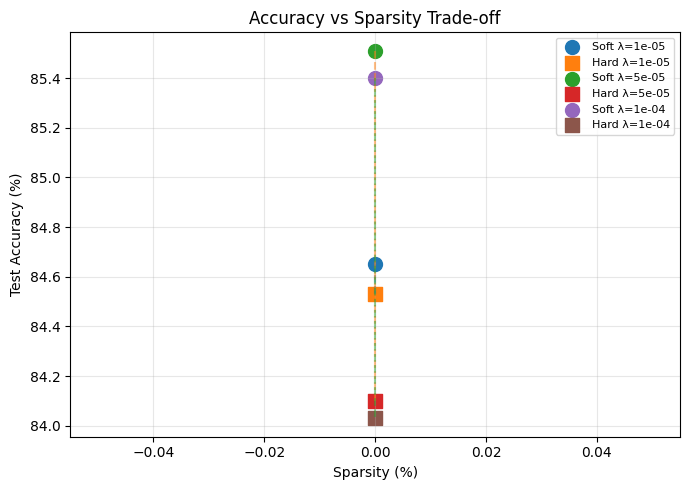

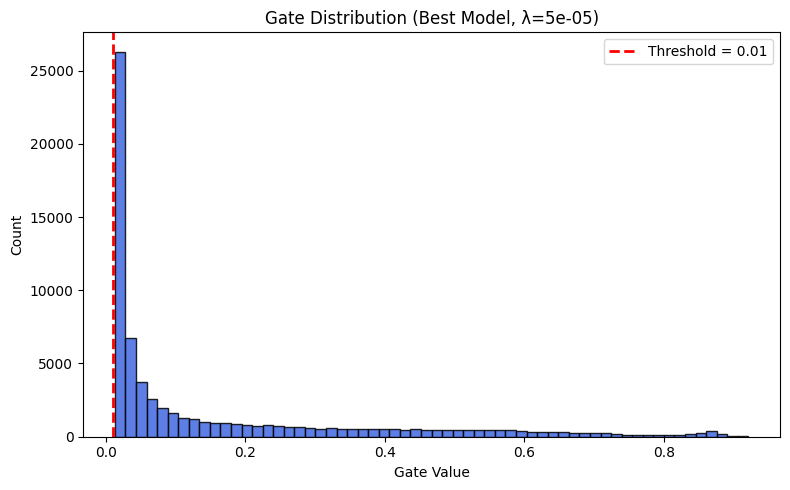

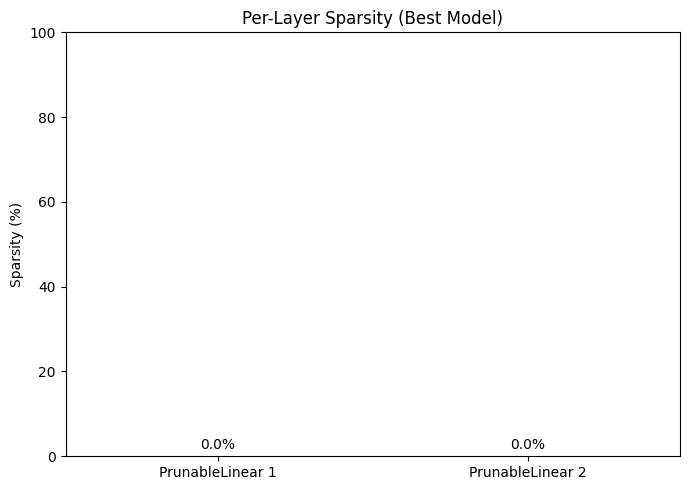

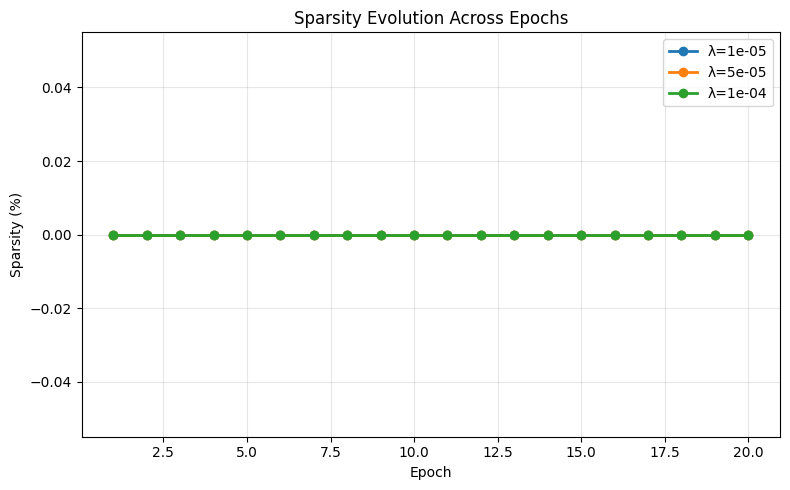

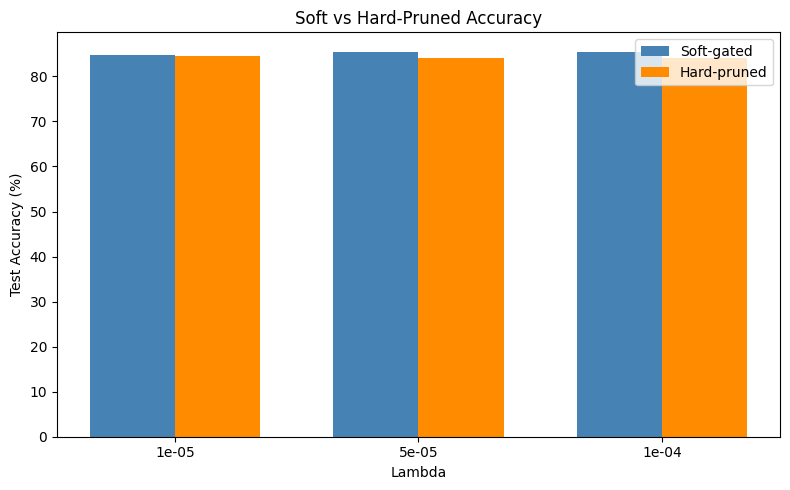

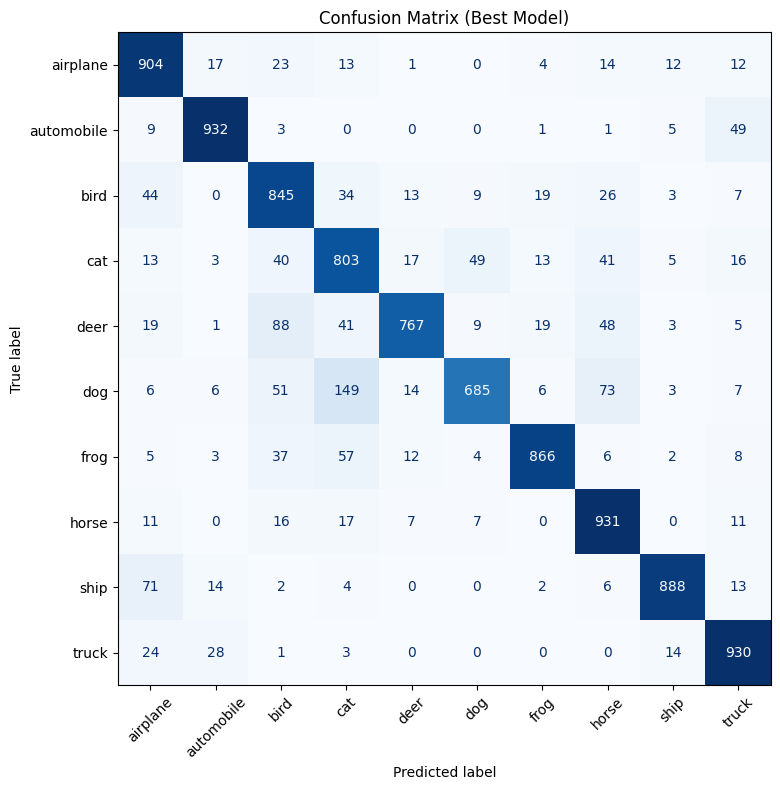

In [63]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

os.makedirs("results", exist_ok=True)

lambdas = [r["lambda"] for r in results]
soft_accs = [r["soft_test_acc"] for r in results]
hard_accs = [r["hard_test_acc"] for r in results]
soft_sparsities = [r["soft_sparsity"] for r in results]
hard_sparsities = [r["hard_sparsity"] for r in results]

plt.figure(figsize=(7, 5))
plt.plot(lambdas, soft_accs, marker='o', linewidth=2, label="Soft-gated accuracy")
plt.plot(lambdas, hard_accs, marker='s', linewidth=2, label="Hard-pruned accuracy")
plt.xscale("log")
plt.xlabel("Lambda (log scale)")
plt.ylabel("Test Accuracy (%)")
plt.title("Lambda vs Test Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("results/lambda_vs_accuracy.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(lambdas, soft_sparsities, marker='o', linewidth=2, label="Soft-gated sparsity")
plt.plot(lambdas, hard_sparsities, marker='s', linewidth=2, label="Hard-pruned sparsity")
plt.xscale("log")
plt.xlabel("Lambda (log scale)")
plt.ylabel("Sparsity (%)")
plt.title("Lambda vs Sparsity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("results/lambda_vs_sparsity.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
for i, lam in enumerate(lambdas):
    plt.scatter(soft_sparsities[i], soft_accs[i], s=100, label=f"Soft λ={lam:.0e}")
    plt.scatter(hard_sparsities[i], hard_accs[i], s=100, marker='s', label=f"Hard λ={lam:.0e}")

for i in range(len(lambdas)):
    plt.plot([soft_sparsities[i], hard_sparsities[i]],
             [soft_accs[i], hard_accs[i]], linestyle='--', alpha=0.5)

plt.xlabel("Sparsity (%)")
plt.ylabel("Test Accuracy (%)")
plt.title("Accuracy vs Sparsity Trade-off")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("results/accuracy_vs_sparsity.png", dpi=300)
plt.show()

best_model = best_model_info["model"]
all_gates = best_model.collect_all_gates().cpu().numpy()

plt.figure(figsize=(8, 5))
plt.hist(all_gates, bins=60, color="royalblue", edgecolor="black", alpha=0.85)
plt.axvline(SPARSITY_THRESHOLD, color="red", linestyle="--", linewidth=2,
            label=f"Threshold = {SPARSITY_THRESHOLD}")
plt.xlabel("Gate Value")
plt.ylabel("Count")
plt.title(f"Gate Distribution (Best Model, λ={best_model_info['lambda']:.0e})")
plt.legend()
plt.tight_layout()
plt.savefig("results/gate_distribution_best_model.png", dpi=300)
plt.show()

layer_names = []
layer_sparsities = []

for idx, layer in enumerate(best_model.prunable_layers()):
    gates = layer.get_gates().detach().view(-1)
    layer_sparsity = (gates < SPARSITY_THRESHOLD).float().mean().item() * 100.0
    layer_names.append(f"PrunableLinear {idx+1}")
    layer_sparsities.append(layer_sparsity)

plt.figure(figsize=(7, 5))
bars = plt.bar(layer_names, layer_sparsities, color=["teal", "orange"])
plt.ylabel("Sparsity (%)")
plt.title("Per-Layer Sparsity (Best Model)")
plt.ylim(0, 100)
for bar, val in zip(bars, layer_sparsities):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.1f}%",
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig("results/per_layer_sparsity.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
for r in results:
    history = r["history"]
    lambda_val = r["lambda"]

    epochs = range(1, len(history["sparsity"]) + 1)
    plt.plot(epochs, history["sparsity"], marker='o', linewidth=2,
             label=f"λ={lambda_val:.0e}")

plt.xlabel("Epoch")
plt.ylabel("Sparsity (%)")
plt.title("Sparsity Evolution Across Epochs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("results/sparsity_evolution.png", dpi=300)
plt.show()

x = np.arange(len(lambdas))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, soft_accs, width, label="Soft-gated", color="steelblue")
plt.bar(x + width/2, hard_accs, width, label="Hard-pruned", color="darkorange")

plt.xticks(x, [f"{lam:.0e}" for lam in lambdas])
plt.xlabel("Lambda")
plt.ylabel("Test Accuracy (%)")
plt.title("Soft vs Hard-Pruned Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("results/soft_vs_hard_accuracy.png", dpi=300)
plt.show()

class_names = train_dataset.classes

best_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = best_model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix (Best Model)")
plt.tight_layout()
plt.savefig("results/confusion_matrix_best_model.png", dpi=300)
plt.show()